In [1]:
# importing required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Churn Modelling Dataset

In [2]:
# reading csv file
df = pd.read_excel(r"C:\Users\agraw\OneDrive\Desktop\Churn_Modelling.xlsx")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# checking information about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
# analysing some statistical information
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
# cheking for null values in dataset
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
# checking if duplicate values are present or not
df.duplicated().sum()

np.int64(0)

In [7]:
# selecting columns with datatype object
df.select_dtypes(include = "object").columns

Index(['Surname', 'Geography', 'Gender'], dtype='object')

In [8]:
# selecting columns with datatype float64 and int64
df.select_dtypes(include = ["float64", "int64"]).columns

Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

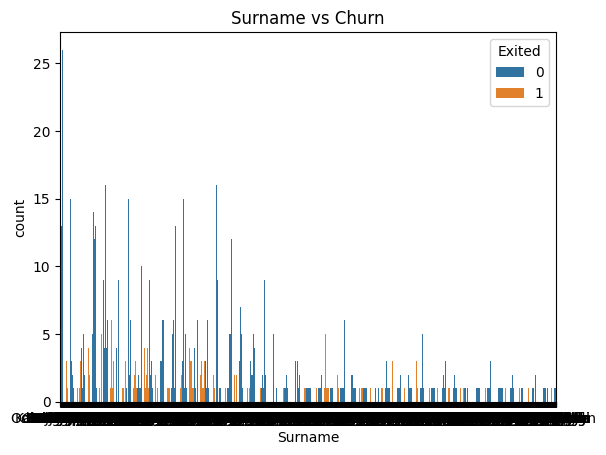

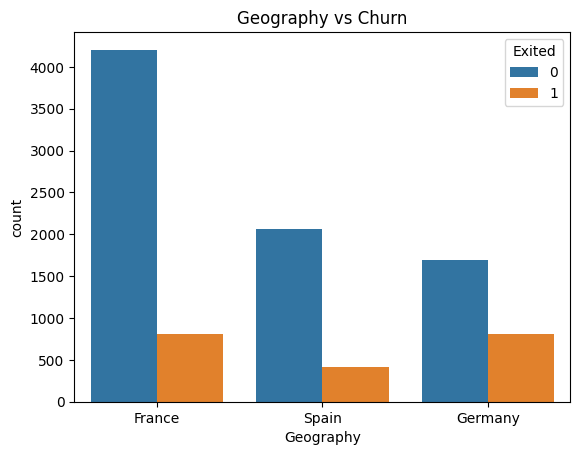

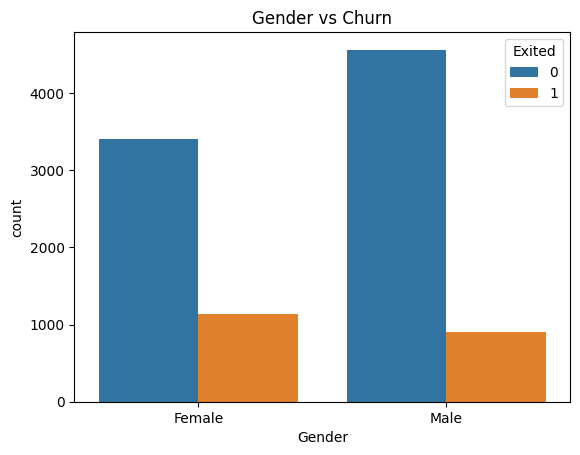

In [9]:
# analysing the trend of object type of properties with the output property
for i in df.select_dtypes(include = "object").columns:
    sns.countplot(x=i, hue='Exited', data=df)
    plt.title(i+" "+"vs Churn")
    plt.show()

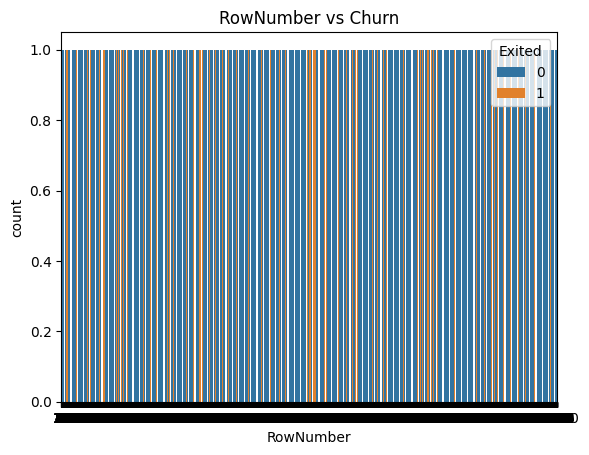

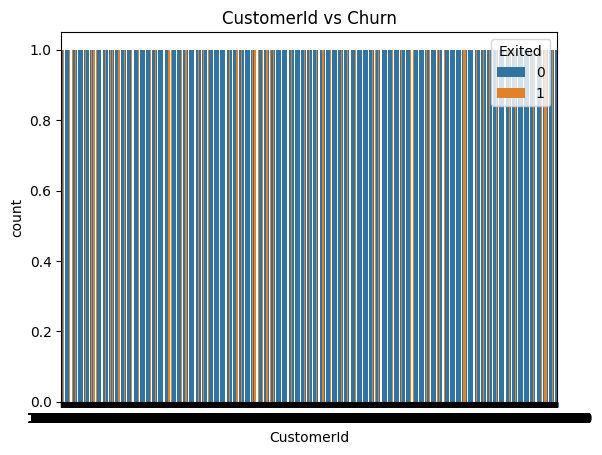

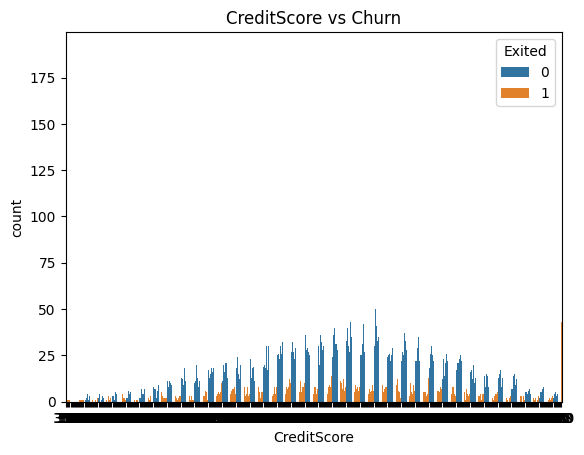

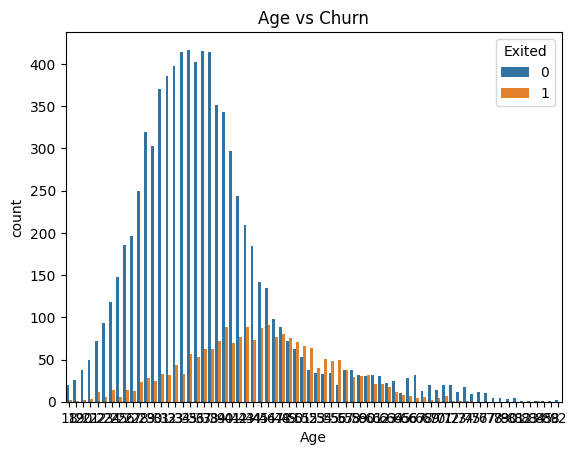

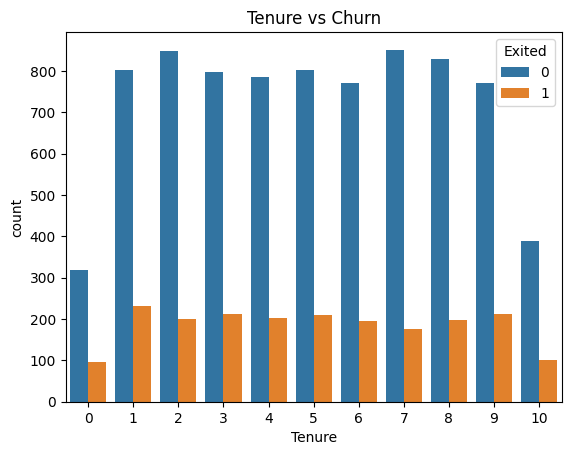

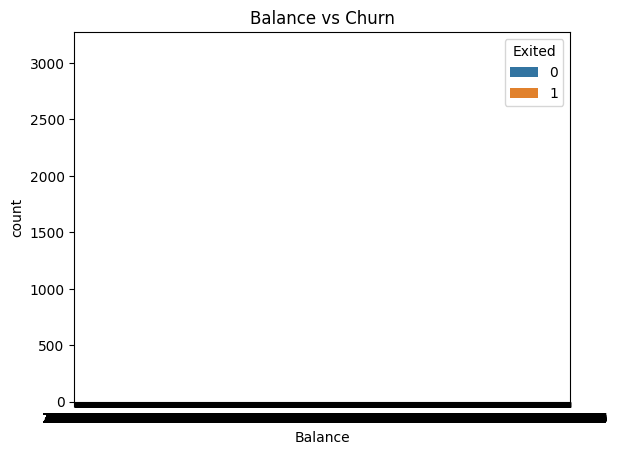

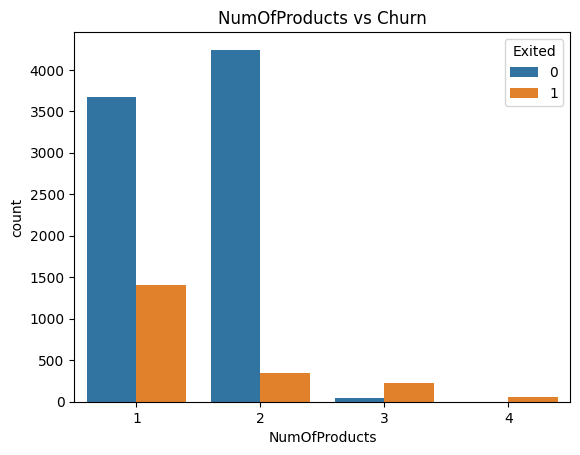

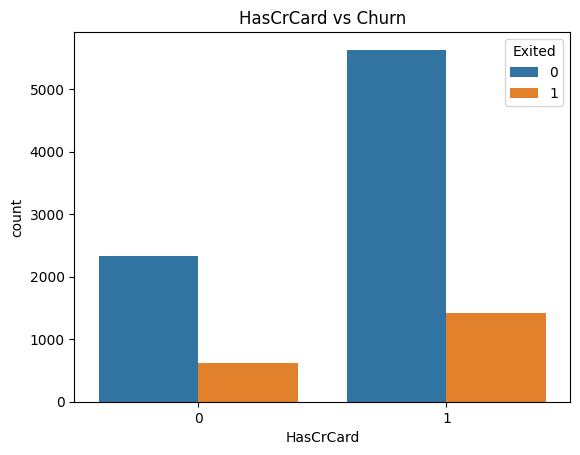

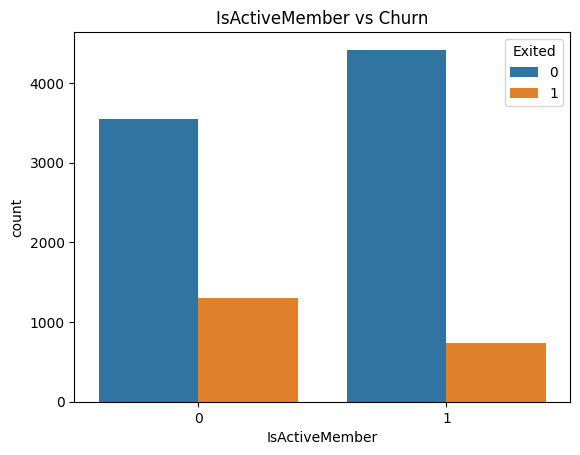

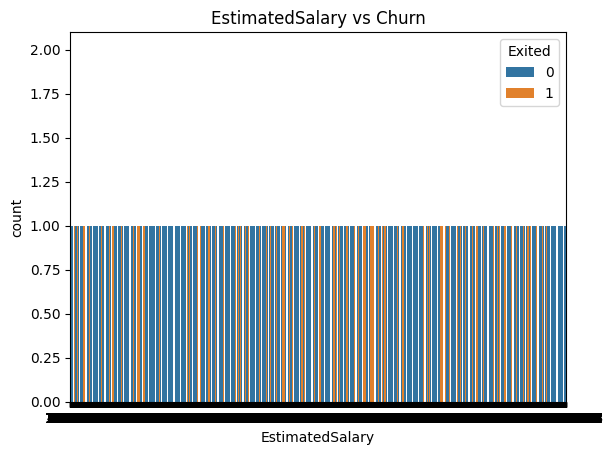

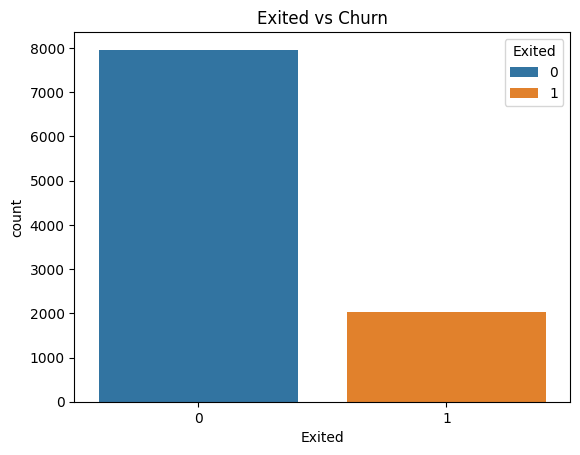

In [10]:
# analysing the trend of float64 and int64 type of properties with the output property
for i in df.select_dtypes(include = ["float64", "int64"]).columns:
    sns.countplot(x=i, hue='Exited', data=df)
    plt.title(i+" "+"vs Churn")
    plt.show()

In [11]:
# dropping some non important columns
df.drop(columns = "Surname", inplace = True)

In [12]:
df.drop(columns = "RowNumber", inplace = True)

In [13]:
df.drop(columns = "CustomerId", inplace = True)

In [14]:
# checking top 5 rows of dataset
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
# finding  mean of an input column with respect to output column
df.groupby('Exited')['Age'].mean()

Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

In [16]:
df.groupby('Exited')['Balance'].mean()

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

In [17]:
df.groupby('Exited')['EstimatedSalary'].mean()

Exited
0     99738.391772
1    101465.677531
Name: EstimatedSalary, dtype: float64

In [18]:
df.groupby('Exited')['Balance'].mean()

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

In [19]:
df.groupby('Exited')['CreditScore'].mean()

Exited
0    651.853196
1    645.351497
Name: CreditScore, dtype: float64

In [20]:
df.select_dtypes(include = "object").columns

Index(['Geography', 'Gender'], dtype='object')

In [21]:
# checking unique values of particular column
print(df["Geography"].unique(), df["Gender"].unique())

['France' 'Spain' 'Germany'] ['Female' 'Male']


In [22]:
# performing encoding of categorical data using map function
df["Geography"] = df["Geography"].map({"France" : 0, "Spain" : 1, "Germany" : 2})
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,Female,42,2,0.00,1,1,1,101348.88,1
1,608,1,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,0,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,0,Female,39,1,0.00,2,0,0,93826.63,0
4,850,1,Female,43,2,125510.82,1,1,1,79084.10,0


In [23]:
# encoding of categorical data using get_dummies method of pandas
df = pd.get_dummies(df, columns=['Gender'], drop_first=True, dtype = "int64")
df.head()

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male
0,619,0,42,2,0.00,1,1,1,101348.88,1,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  int64  
 2   Age              10000 non-null  int64  
 3   Tenure           10000 non-null  int64  
 4   Balance          10000 non-null  float64
 5   NumOfProducts    10000 non-null  int64  
 6   HasCrCard        10000 non-null  int64  
 7   IsActiveMember   10000 non-null  int64  
 8   EstimatedSalary  10000 non-null  float64
 9   Exited           10000 non-null  int64  
 10  Gender_Male      10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


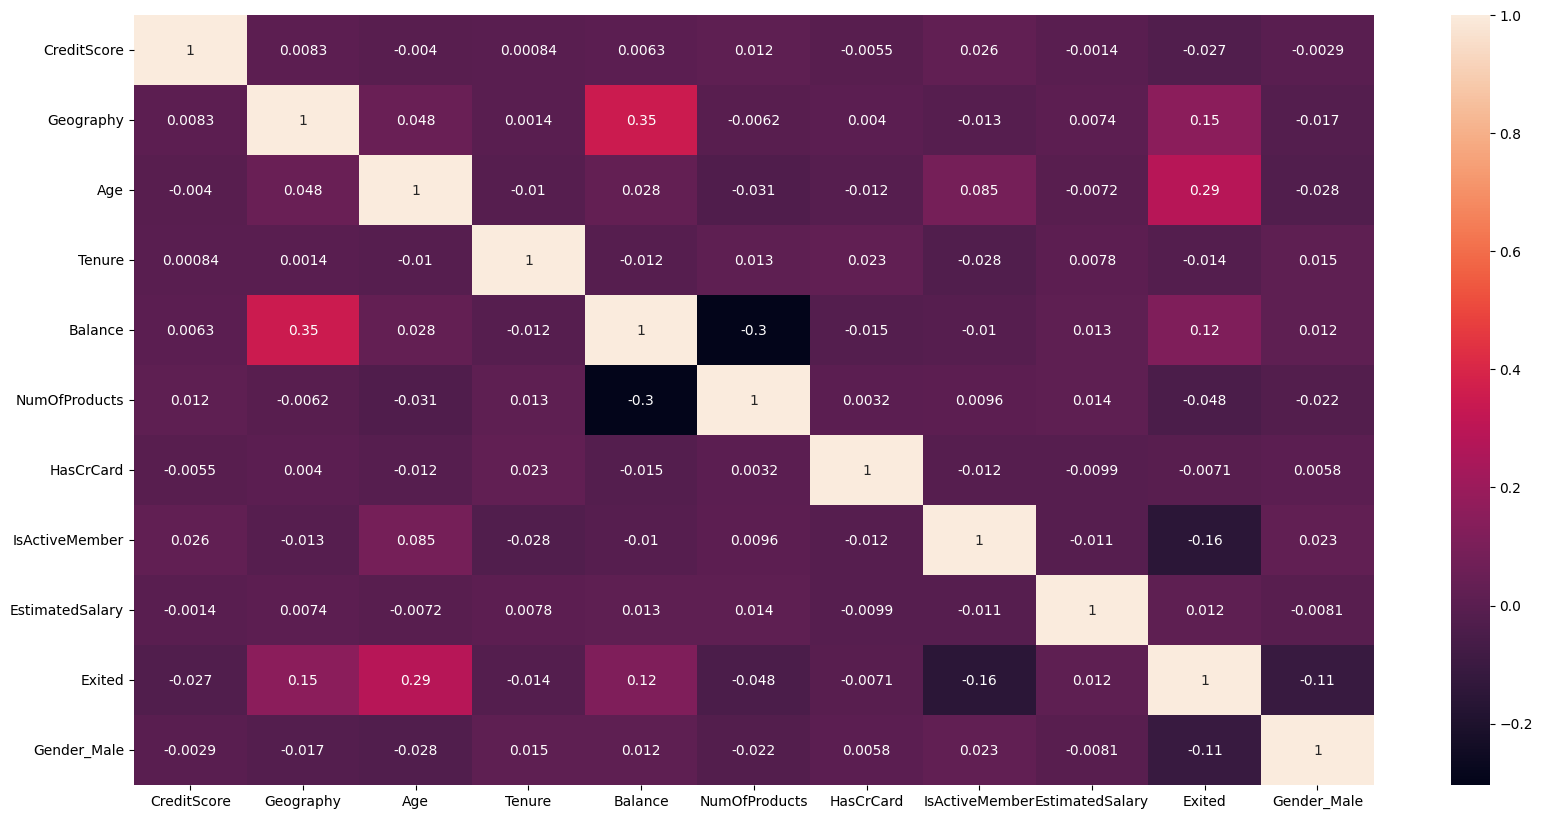

In [25]:
# plotting heatmap for finding correlation between every column to others
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), annot = True)
plt.show()

In [26]:
# sorting values on the basis of kind of correlation
corr_target = df.corr()['Exited'].sort_values(ascending=False)
print(corr_target)

Exited             1.000000
Age                0.285323
Geography          0.153771
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
Gender_Male       -0.106512
IsActiveMember    -0.156128
Name: Exited, dtype: float64


In [27]:
# age is the most important feature for exited

In [28]:
df.columns

Index(['CreditScore', 'Geography', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'Gender_Male'],
      dtype='object')

In [29]:
# splitting , training data
x = df[['CreditScore', 'Geography', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 
       'Gender_Male']]
y = df["Exited"]
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state= 42)

In [30]:
# standardization of testing and training data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_test = scaler.fit_transform(x_test)
x_train = scaler.fit_transform(x_train)

In [31]:
# applying logistic regression algorithm 
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)

# printing score
print(lr.score(x_test, y_test)*100, lr.score(x_train, y_train)*100)

81.45 81.125


In [32]:
# finding accuracy score, confusion matrix analysis, classification report preparing
y_pred = lr.predict(x_test)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, y_pred))

0.8145


In [33]:
# printing confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1543,   64],
       [ 307,   86]])

# Synthetic Fraud Dataset

In [34]:
# reading csv file
df = pd.read_csv(r"C:\Users\agraw\OneDrive\Desktop\synthetic_fraud_dataset.csv")
df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


In [35]:
# checking information about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [36]:
# checking for information about statistics
df.describe()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000
max,9999.00000,999.000000,11628.213881,23.000000,0.998737,0.999603,1.000000


In [37]:
# checking for null values
df.isnull().sum()

transaction_id       0
user_id              0
amount               0
transaction_type     0
merchant_category    0
country              0
hour                 0
device_risk_score    0
ip_risk_score        0
is_fraud             0
dtype: int64

In [38]:
# checking for duplicate data
df.duplicated().sum()

np.int64(0)

In [39]:
# selecting columns having dtype object
df.select_dtypes(include = "object").columns

Index(['transaction_type', 'merchant_category', 'country'], dtype='object')

In [40]:
# selecting columns having dtype int64 and float64
df.select_dtypes(include = ["int64", "float64"]).columns

Index(['transaction_id', 'user_id', 'amount', 'hour', 'device_risk_score',
       'ip_risk_score', 'is_fraud'],
      dtype='object')

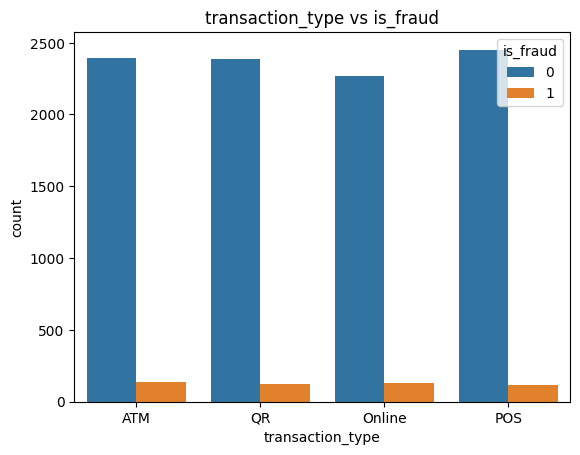

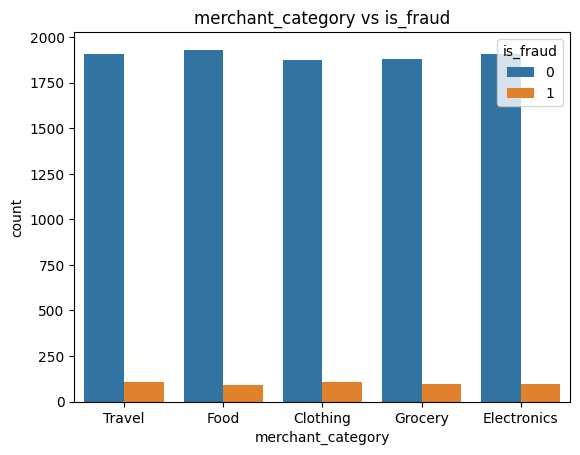

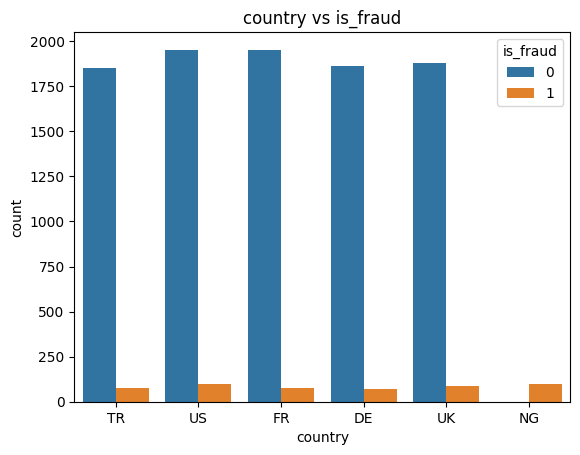

In [41]:
# plotting countplot to analyse the behaviour of object type of columns with output
for i in df.select_dtypes(include = "object").columns:
    sns.countplot(x=i, hue='is_fraud', data=df)
    plt.title(i+" "+"vs is_fraud")
    plt.show()

In [42]:
# printing mean value of every int and float column with respect to output column
for i in df.select_dtypes(include = ["int64", "float64"]).columns:
    print(df.groupby('is_fraud')[i].mean())

is_fraud
0    4749.5
1    9749.5
Name: transaction_id, dtype: float64
is_fraud
0    499.650947
1    507.806000
Name: user_id, dtype: float64
is_fraud
0     100.277751
1    1657.577984
Name: amount, dtype: float64
is_fraud
0    14.469684
1    10.018000
Name: hour, dtype: float64
is_fraud
0    0.148290
1    0.857951
Name: device_risk_score, dtype: float64
is_fraud
0    0.149558
1    0.851770
Name: ip_risk_score, dtype: float64
is_fraud
0    0.0
1    1.0
Name: is_fraud, dtype: float64


In [43]:
# dropping particular unspecific column
df.drop(columns = "hour", inplace = True)
df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,0.098129,0.027542,0


In [44]:
# finding unique values in object dtype columns
c = df.select_dtypes(include="object").columns
for i in c:
    print(df[i].unique())

['ATM' 'QR' 'Online' 'POS']
['Travel' 'Food' 'Clothing' 'Grocery' 'Electronics']
['TR' 'US' 'FR' 'DE' 'UK' 'NG']


In [45]:
# encoding of categorical data using get_dummies mathod of pandas
df = pd.get_dummies(
    df,columns=['transaction_type','merchant_category','country'],drop_first=True,dtype="int64")

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   transaction_id                 10000 non-null  int64  
 1   user_id                        10000 non-null  int64  
 2   amount                         10000 non-null  float64
 3   device_risk_score              10000 non-null  float64
 4   ip_risk_score                  10000 non-null  float64
 5   is_fraud                       10000 non-null  int64  
 6   transaction_type_Online        10000 non-null  int64  
 7   transaction_type_POS           10000 non-null  int64  
 8   transaction_type_QR            10000 non-null  int64  
 9   merchant_category_Electronics  10000 non-null  int64  
 10  merchant_category_Food         10000 non-null  int64  
 11  merchant_category_Grocery      10000 non-null  int64  
 12  merchant_category_Travel       10000 non-null  

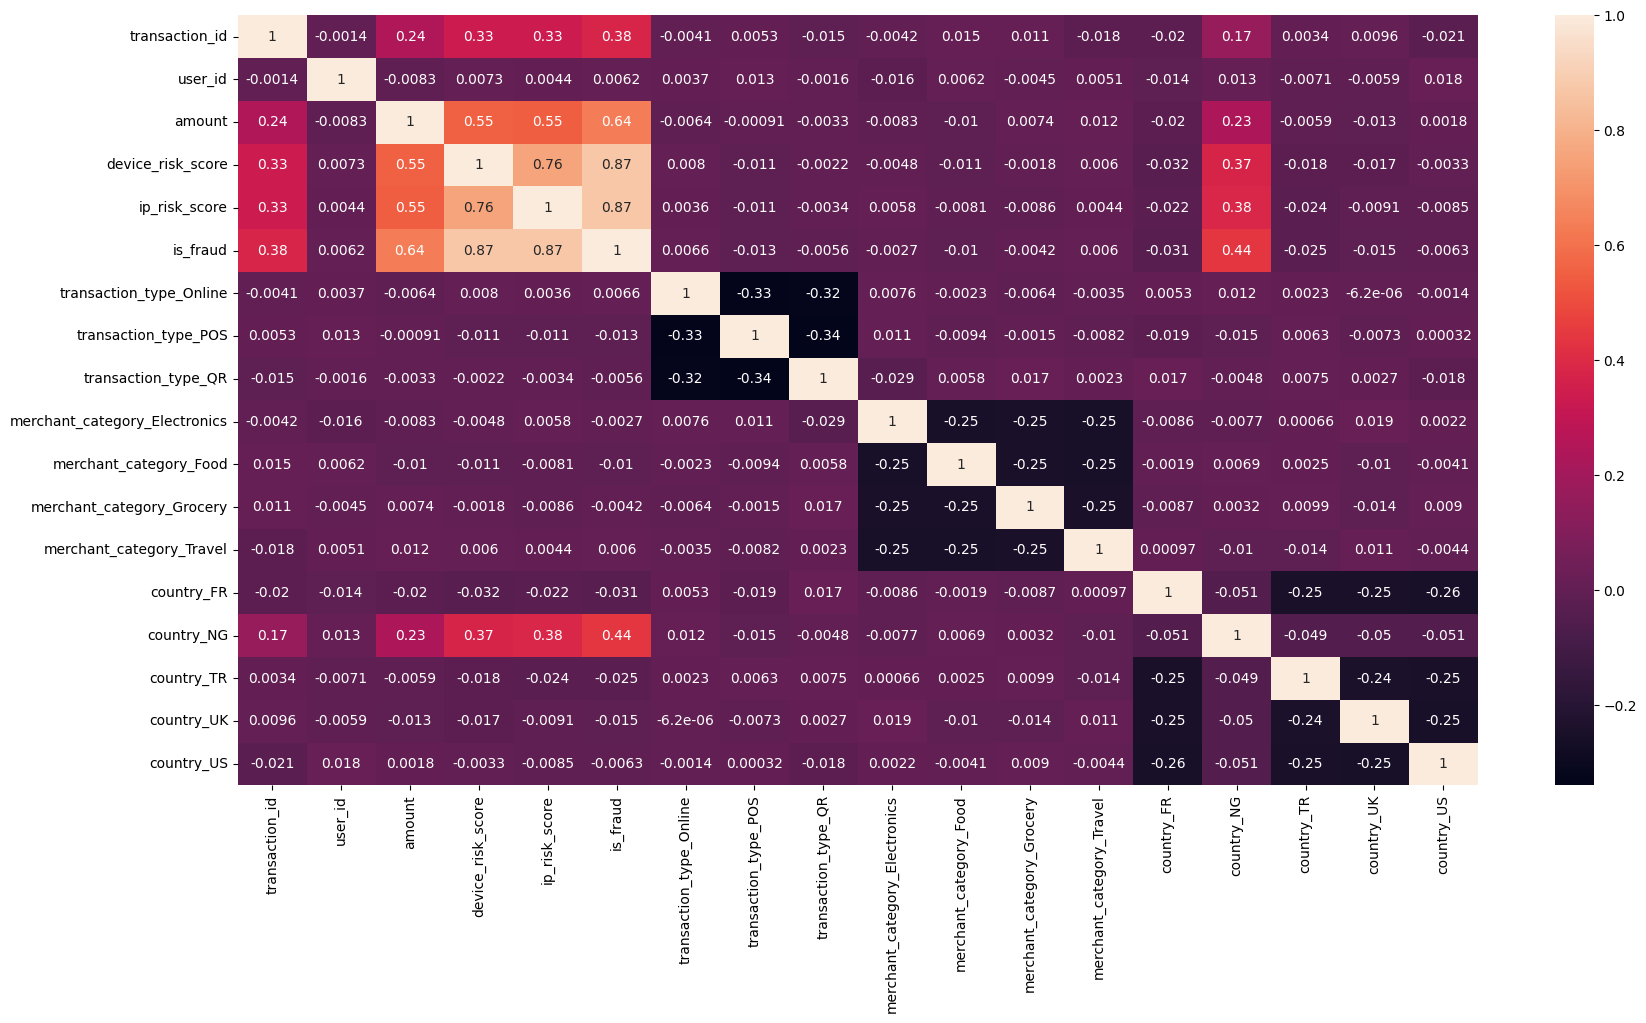

In [47]:
# plotting heatmap to find corellation between numerical type of columns
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), annot = True)
plt.show()

In [48]:
# sorting columns on the basis of correlation with output
corr_target = df.corr()['is_fraud'].sort_values(ascending=False)
print(corr_target)

is_fraud                         1.000000
device_risk_score                0.871989
ip_risk_score                    0.870738
amount                           0.638435
country_NG                       0.438086
transaction_id                   0.377492
transaction_type_Online          0.006610
user_id                          0.006165
merchant_category_Travel         0.006005
merchant_category_Electronics   -0.002692
merchant_category_Grocery       -0.004208
transaction_type_QR             -0.005612
country_US                      -0.006251
merchant_category_Food          -0.010451
transaction_type_POS            -0.013023
country_UK                      -0.015300
country_TR                      -0.024890
country_FR                      -0.031216
Name: is_fraud, dtype: float64


In [49]:
# device_risk_score is the most important feature for exited

In [50]:
df.columns

Index(['transaction_id', 'user_id', 'amount', 'device_risk_score',
       'ip_risk_score', 'is_fraud', 'transaction_type_Online',
       'transaction_type_POS', 'transaction_type_QR',
       'merchant_category_Electronics', 'merchant_category_Food',
       'merchant_category_Grocery', 'merchant_category_Travel', 'country_FR',
       'country_NG', 'country_TR', 'country_UK', 'country_US'],
      dtype='object')

In [51]:
# splitting input and ouyput
x = df[['transaction_id', 'user_id', 'amount', 'device_risk_score',
       'ip_risk_score', 'transaction_type_Online',
       'transaction_type_POS', 'transaction_type_QR',
       'merchant_category_Electronics', 'merchant_category_Food',
       'merchant_category_Grocery', 'merchant_category_Travel', 'country_FR',
       'country_NG', 'country_TR', 'country_UK', 'country_US']]
y = df[ 'is_fraud']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state= 42)

In [52]:
# standardization of testing and training data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_test = scaler.fit_transform(x_test)
x_train = scaler.fit_transform(x_train)

In [53]:
# applying logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)

# printing testing and training socre
print(lr.score(x_test, y_test)*100, lr.score(x_train, y_train)*100)

100.0 100.0


In [54]:
# checking accuracy score, confusion matrix analysis, preparing classification report
y_pred = lr.predict(x_test)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, y_pred), confusion_matrix(y_test, y_pred))

1.0 [[1887    0]
 [   0  113]]


# Demand Forecasting Dataset

In [55]:
# reading csv file
df = pd.read_csv(r"C:\Users\agraw\OneDrive\Desktop\demand_forecasting_dataset (1).csv")
df.head()

,date,product_id,category_id,store_id,historical_sales,price,promotion_flag,holiday_flag,economic_index,target_demand
0,2022-01-02,1043,4,9,16,48.29,0,0,84.07,8
1,2022-01-02,1012,4,2,25,44.01,0,0,106.87,22
2,2022-01-03,1003,5,4,26,9.44,1,0,104.98,29
3,2022-01-03,1005,4,1,23,5.42,1,1,92.75,22
4,2022-01-04,1011,1,5,12,21.86,1,1,103.60,27


In [56]:
# checking information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4921 entries, 0 to 4920
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              4921 non-null   object 
 1   product_id        4921 non-null   int64  
 2   category_id       4921 non-null   int64  
 3   store_id          4921 non-null   int64  
 4   historical_sales  4921 non-null   int64  
 5   price             4921 non-null   float64
 6   promotion_flag    4921 non-null   int64  
 7   holiday_flag      4921 non-null   int64  
 8   economic_index    4921 non-null   float64
 9   target_demand     4921 non-null   int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 384.6+ KB


In [57]:
# checking for some statistical information
df.describe()

,product_id,category_id,store_id,historical_sales,price,promotion_flag,holiday_flag,economic_index,target_demand
count,4921.000000,4921.000000,4921.000000,4921.000000,4921.000000,4921.000000,4921.000000,4921.000000,4921.000000
mean,1024.328389,3.018492,5.453363,20.039626,27.209683,0.291607,0.152408,99.834089,22.421459
std,14.297004,1.422905,2.883354,4.398985,12.923657,0.454549,0.359452,9.870727,7.489883
min,1000.000000,1.000000,1.000000,5.000000,5.000000,0.000000,0.000000,69.320000,1.000000
25%,1012.000000,2.000000,3.000000,17.000000,15.950000,0.000000,0.000000,92.950000,17.000000
50%,1024.000000,3.000000,5.000000,20.000000,27.120000,0.000000,0.000000,99.570000,22.000000
75%,1037.000000,4.000000,8.000000,23.000000,38.370000,1.000000,0.000000,106.520000,27.000000
max,1049.000000,5.000000,10.000000,37.000000,49.990000,1.000000,1.000000,142.990000,53.000000


In [58]:
# checking for null values
df.isnull().sum()

date                0
product_id          0
category_id         0
store_id            0
historical_sales    0
price               0
promotion_flag      0
holiday_flag        0
economic_index      0
target_demand       0
dtype: int64

In [59]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [60]:
# printing columns of dataset
df.columns

Index(['date', 'product_id', 'category_id', 'store_id', 'historical_sales',
       'price', 'promotion_flag', 'holiday_flag', 'economic_index',
       'target_demand'],
      dtype='object')

In [61]:
# converting object kind of date and time column with date_time dtype
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4921 entries, 0 to 4920
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              4921 non-null   datetime64[ns]
 1   product_id        4921 non-null   int64         
 2   category_id       4921 non-null   int64         
 3   store_id          4921 non-null   int64         
 4   historical_sales  4921 non-null   int64         
 5   price             4921 non-null   float64       
 6   promotion_flag    4921 non-null   int64         
 7   holiday_flag      4921 non-null   int64         
 8   economic_index    4921 non-null   float64       
 9   target_demand     4921 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(7)
memory usage: 384.6 KB


In [63]:
# seperating date, month and year columns from date column and changing dtype from date-time to int
df['Day'] = df['date'].dt.day.astype(int)
df['Month'] = df['date'].dt.month.astype(int)
df['Year'] = df['date'].dt.year.astype(int)
df.drop(columns = "date", inplace = True)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4921 entries, 0 to 4920
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        4921 non-null   int64  
 1   category_id       4921 non-null   int64  
 2   store_id          4921 non-null   int64  
 3   historical_sales  4921 non-null   int64  
 4   price             4921 non-null   float64
 5   promotion_flag    4921 non-null   int64  
 6   holiday_flag      4921 non-null   int64  
 7   economic_index    4921 non-null   float64
 8   target_demand     4921 non-null   int64  
 9   Day               4921 non-null   int64  
 10  Month             4921 non-null   int64  
 11  Year              4921 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 461.5 KB


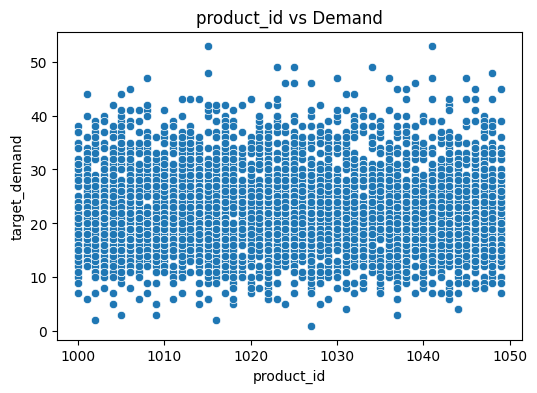

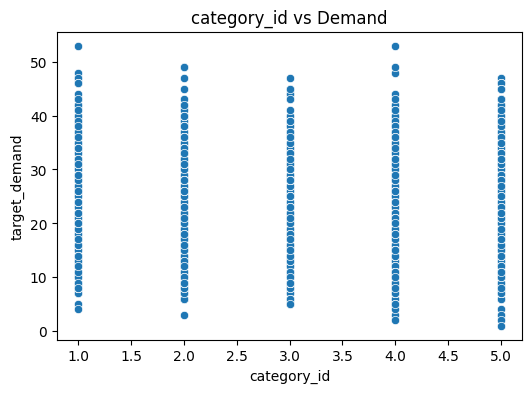

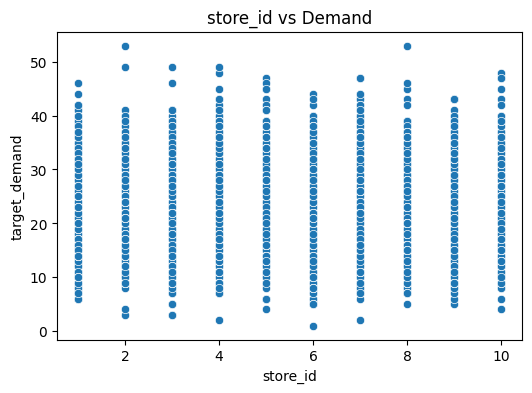

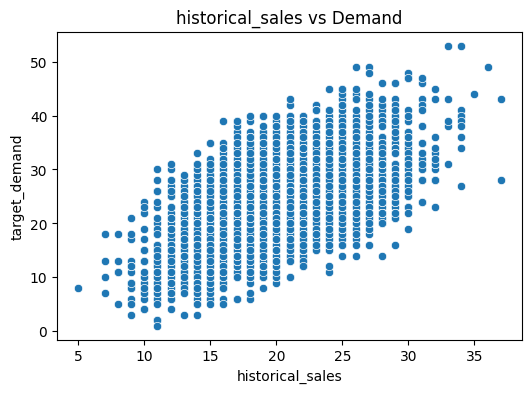

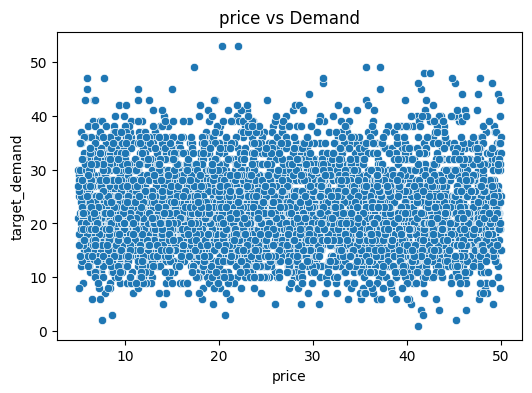

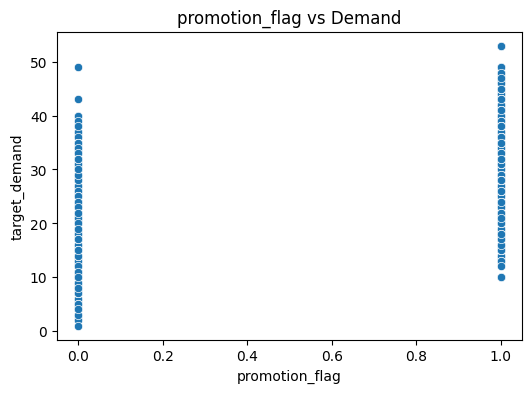

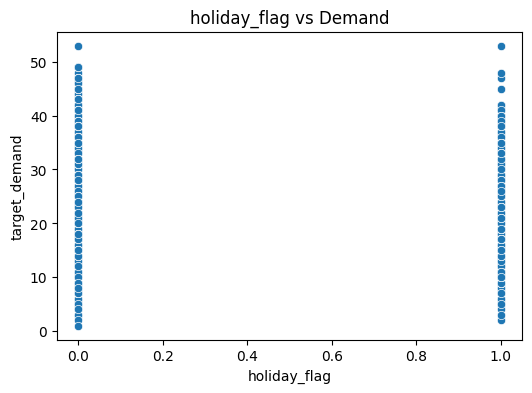

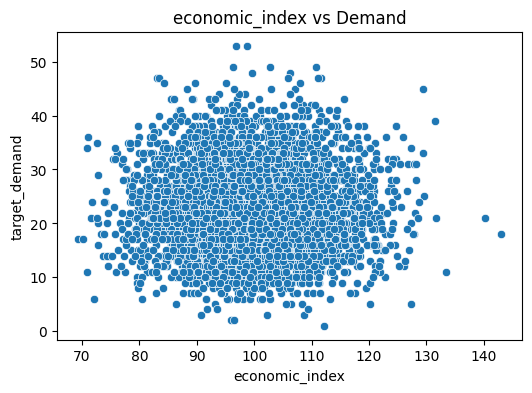

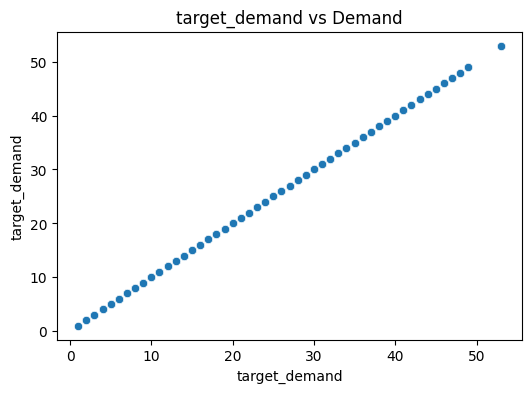

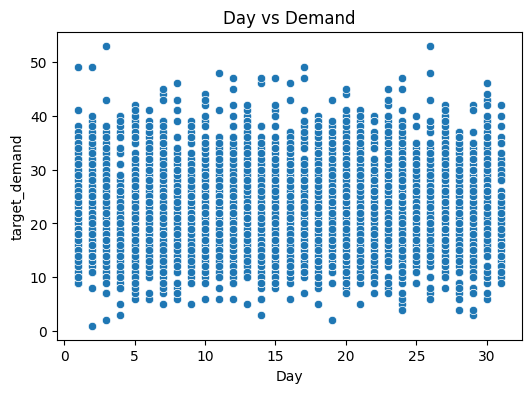

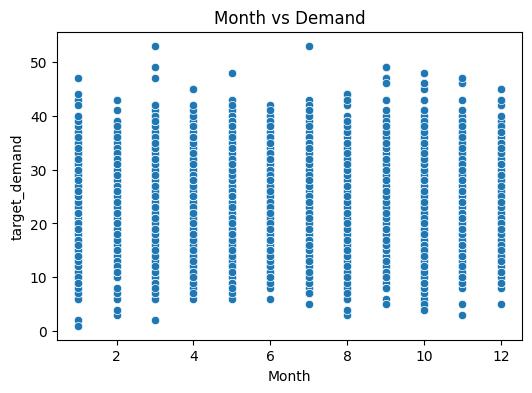

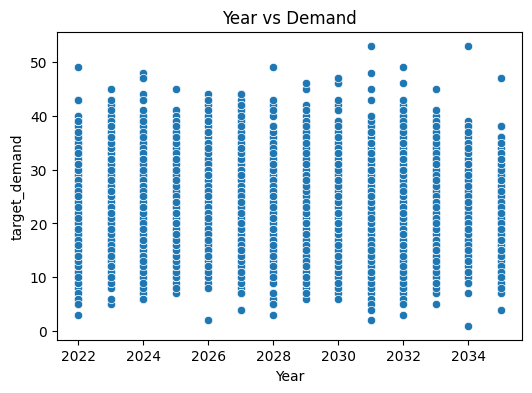

In [65]:
# plotting scatterplot to analyse the trend of float64 and int64 with target column
for i in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=i, y='target_demand', data=df)

    plt.title(i+' vs Demand')
    plt.xlabel(i)
    plt.ylabel('target_demand')
    plt.show()

In [66]:
# printing columns of dataset
df.columns

Index(['product_id', 'category_id', 'store_id', 'historical_sales', 'price',
       'promotion_flag', 'holiday_flag', 'economic_index', 'target_demand',
       'Day', 'Month', 'Year'],
      dtype='object')

In [67]:
# dropping or removing columns from dataset
df.drop(columns = ['store_id', 'category_id',  'economic_index',
        "product_id"], inplace = True)

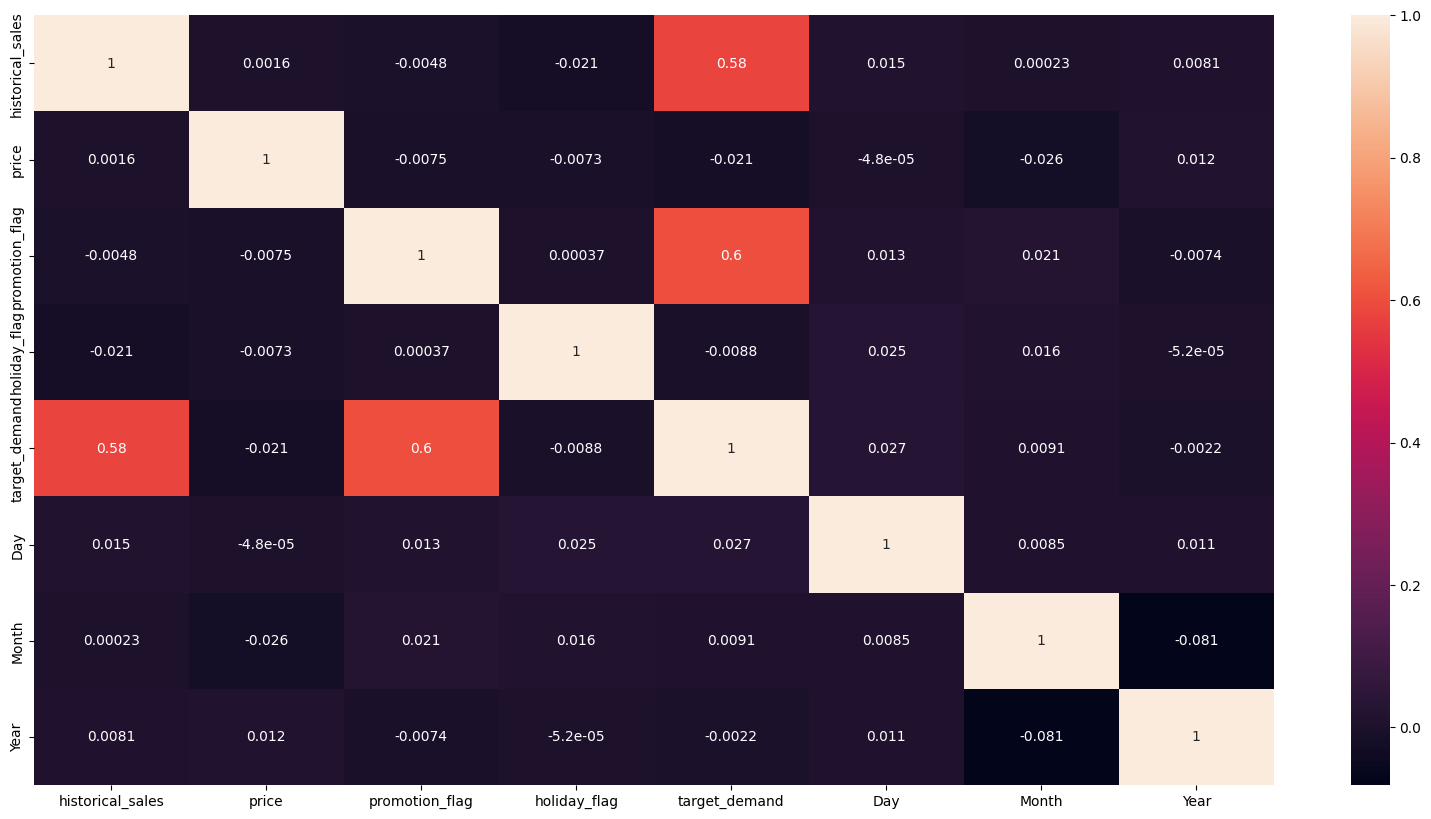

In [68]:
# plotting heatmap to find correlation between each column
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), annot = True)
plt.show()

In [69]:
# finding sequence of correlation
corr_target = df.corr()['target_demand'].sort_values(ascending=False)
print(corr_target)

target_demand       1.000000
promotion_flag      0.600960
historical_sales    0.579819
Day                 0.026925
Month               0.009053
Year               -0.002229
holiday_flag       -0.008765
price              -0.021202
Name: target_demand, dtype: float64


In [70]:
# promotion_flag is highly related to target

In [71]:
df.columns

Index(['historical_sales', 'price', 'promotion_flag', 'holiday_flag',
       'target_demand', 'Day', 'Month', 'Year'],
      dtype='object')

In [72]:
# splitting data, testing and training
x = df[['historical_sales', 'promotion_flag', 'price', 'holiday_flag','Day', 'Month', 'Year']]
y = df['target_demand']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state= 42)

In [73]:
# standardization of testing and training data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_test = scaler.transform(x_test)
x_train = scaler.fit_transform(x_train)

NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
# applying linear regression algorithm 
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
print(lr.score(x_test, y_test)*100, lr.score(x_train, y_train)*100)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}

In [ ]:
results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
print(results_df.sort_values(by="R2 Score", ascending=False))

# Recommendation Dataset